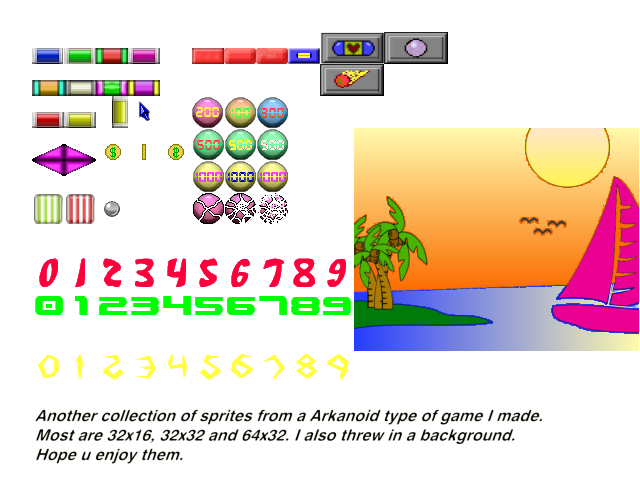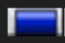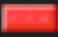ball.png

### Clase 7:
Reutilizando el Motor - Creando un Arkanoid
### Objetivo de la clase:
 Adaptar nuestro motor existente para crear una versión funcional del clásico juego Arkanoid. Esto nos enseñará a manejar listas de objetos (los ladrillos), a implementar físicas de rebote más complejas y a definir nuevas condiciones de victoria y derrota.



### Parte 1: Preparando el Escenario
1. Un Nuevo Archivo, un Nuevo Juego
Para empezar, crea una copia de tu archivo de la clase 6 y llámalo arkanoid.py. Esto nos permite mantener nuestro juego anterior intacto y empezar a trabajar en el nuevo.

Dentro de arkanoid.py, vamos a eliminar o comentar la creación de los objetos moneda y enemigo. Ya no los necesitamos. Nuestro jugador ahora será una pala (paddle).

2. La Pala y la Pelota: Nuestros Nuevos Actores
La Pala (Player): La clase Player que ya tenemos es casi perfecta. Solo necesita una modificación: no debe poder moverse hacia arriba o hacia abajo.



        # Dentro de la clase Player, en el método mover()
        def mover(self, teclas):
            if teclas[pygame.K_LEFT]:
                self.rect.x -= self.velocidad
            if teclas[pygame.K_RIGHT]:
                self.rect.x += self.velocidad
            # ¡Eliminamos el código para K_UP y K_DOWN!


La Pelota (Ball): Necesitamos una nueva clase para la pelota. Será muy parecida a nuestro antiguo Enemy, ya que se mueve sola, pero su lógica de rebote será un poco más sofisticada.

    import pygame

    class Ball:
        def __init__(self, x, y):
            self.image = pygame.image.load('assets/ball.png').convert_alpha() # Necesitarás una imagen para la pelota
            self.rect = self.image.get_rect(center=(x, y))
            self.velocidad_x = 4
            self.velocidad_y = -4 # Empieza moviéndose hacia arriba

        def update(self):
            self.rect.x += self.velocidad_x
            self.rect.y += self.velocidad_y

            # Rebote con las paredes laterales y superior
            if self.rect.left <= 0 or self.rect.right >= ANCHO:
                self.velocidad_x *= -1
            if self.rect.top <= 0:
                self.velocidad_y *= -1

        def dibujar(self, superficie):
            superficie.blit(self.image, self.rect)
3. El Muro de Ladrillos: Manejando Listas
No podemos crear una variable para cada ladrillo (ladrillo1, ladrillo2, etc.). ¡Sería una locura! La solución es usar una lista de Python.

Crearemos una clase Brick y luego usaremos un bucle for para crear muchas instancias y guardarlas en una lista.



    class Brick:
        def __init__(self, x, y):
            self.image = pygame.image.load('assets/brick.png').convert_alpha() # Necesitarás una imagen para el ladrillo
            self.rect = self.image.get_rect(topleft=(x, y))

        def dibujar(self, superficie):
            superficie.blit(self.image, self.rect)


En la clase game agregamos:

    # --- ANTES DEL BUCLE PRINCIPAL ---
    ladrillos = []
    NUM_LADRILLOS_FILA = 10
    ANCHO_LADRILLO = ANCHO // NUM_LADRILLOS_FILA

    for fila in range(5): # 5 filas de ladrillos
        for col in range(NUM_LADRILLOS_FILA): # 10 ladrillos por fila
            ladrillo = Brick(col * ANCHO_LADRILLO, fila * 40 + 50) # +50 para dejar espacio arriba
            ladrillos.append(ladrillo)




### Explicación:

ladrillos = []: Creamos una lista vacía.

Usamos dos bucles for anidados para crear una cuadrícula. Calculamos la posición x e y de cada ladrillo basándonos en su número de fila y columna.

ladrillos.append(ladrillo): Añadimos cada nuevo objeto Brick a nuestra lista.

### Parte 2: Físicas e Interacciones
1. Dibujando y Actualizando Múltiples Objetos
Para dibujar todos los ladrillos, simplemente recorremos la lista en la sección de RENDER y llamamos al método dibujar de cada uno.



        # Dentro del bucle, en la sección RENDER
        # ... (dibujar pala y pelota)
        for ladrillo in ladrillos:
            ladrillo.dibujar(PANTALLA)

2. Rebote de la Pelota con la Pala
Esta es una de las interacciones clave. Usaremos colliderect como antes, pero con una pequeña mejora: si la pelota golpea la pala, siempre rebotará hacia arriba para evitar que se quede "atrapada".



        # Dentro del bucle, en la sección UPDATE
        pelota.update()

        # Colisión pelota con pala
        if pelota.rect.colliderect(pala.rect):
            pelota.velocidad_y *= -1 # Siempre rebota hacia arriba
            # Opcional: un pequeño ajuste para evitar que se pegue
            pelota.rect.bottom = pala.rect.top

3. Destruyendo Ladrillos
 Recorremos la lista y comprobamos la colisión de la pelota con cada ladrillo.

Si hay una colisión, invertimos la velocidad de la pelota y eliminamos el ladrillo de la lista.



    # Dentro del bucle, en la sección UPDATE

    # Usamos una copia de la lista [:] para poder eliminar elementos de forma segura
    for ladrillo in ladrillos[:]:
        if pelota.rect.colliderect(ladrillo.rect):
            ladrillos.remove(ladrillo) # Eliminamos el ladrillo de la lista
            pelota.velocidad_y *= -1 # La pelota rebota
            # Aquí iría el sonido de romper ladrillo
            break # Salimos del bucle para evitar múltiples colisiones en un frame


Explicación Clave:
 for ladrillo in ladrillos[:]. El [:] crea una copia temporal de la lista. Nunca debes eliminar elementos de una lista mientras la estás recorriendo directamente, ya que puede causar errores extraños. Al recorrer una copia y eliminar de la original, evitamos este problema.


### Parte 3: Ganar y Perder
1. Condición de Derrota
En Arkanoid, se pierde si la pelota cae por debajo de la pantalla.


        # Dentro del bucle, en UPDATE
        if pelota.rect.top > ALTO:
            estado_juego = 'game_over'
            # Aquí iría el sonido de perder y parar la música

2. Condición de Victoria (10 min)
Se gana si se destruyen todos los ladrillos. ¿Cómo sabemos eso? ¡Muy fácil! Si nuestra lista de ladrillos está vacía.



        # Dentro del bucle, en UPDATE, después del bucle de colisiones
        if not ladrillos: # Esto es True si la lista está vacía
            estado_juego = 'victoria' # Un nuevo estado de juego
            # Aquí iría el sonido de victoria

3. Pantalla de Victoria y Reinicio
Necesitamos añadir un nuevo elif a nuestro gestor de estados para la pantalla de victoria, que puede mostrar un mensaje y ofrecer reiniciar el juego de la misma forma que la pantalla de "Game Over". El reinicio ahora implicaría volver a generar toda la lista de ladrillos.

        # En el gestor de estados
        elif estado_juego == 'victoria':
            # Dibujar un mensaje de "¡GANASTE!"
            # Esperar a que se presione ESPACIO para reiniciar

        # En la lógica de reinicio (cuando se presiona espacio)
        def reiniciar_juego():
            # ... resetear pala, pelota, puntuación
            global ladrillos
            ladrillos = [] # Vaciar la lista por si acaso
            # Volver a ejecutar el código que genera la cuadrícula de ladrillos
            for fila in range(5):
                for col in range(NUM_LADRILLOS_FILA):
                    # ... crear y añadir ladrillo a la lista


### Cierre y Próximos Pasos
Resumen de Hoy: Hemos tomado nuestro motor y, con unas pocas modificaciones y nuevas clases, hemos creado un  juego totalmente diferente. Hemos aprendido a manejar grupos de objetos usando listas.


### Tarea/Desafío:

Haz que algunos ladrillos tengan un color diferente. ¿Cómo podrías hacer que esos ladrillos necesiten dos golpes para romperse? (Pista: añade una variable vida a la clase Brick).

Modifica el rebote con la pala. Haz que el ángulo de rebote de la pelota dependa de en qué parte de la pala golpee (si golpea en el lado izquierdo, sale hacia la izquierda; si golpea en el derecho, sale hacia la derecha).

## Código completo de la clase

    import pygame

    from utils.utils import ANCHO


    class Ball:
        def __init__(self, x, y):
            self.image = pygame.image.load('assets/sprites/ball.png').convert_alpha() # Necesitarás una imagen para la pelota
            self.rect = self.image.get_rect(center=(x, y))
            self.velocidad_x = 4
            self.velocidad_y = -4 # Empieza moviéndose hacia arriba

        def update(self):
            self.rect.x += self.velocidad_x
            self.rect.y += self.velocidad_y

            # Rebote con las paredes laterales y superior
            if self.rect.left <= 0 or self.rect.right >= ANCHO:
                self.velocidad_x *= -1
            if self.rect.top <= 0:
                self.velocidad_y *= -1

        def dibujar(self, superficie):
            superficie.blit(self.image, self.rect)

    import pygame

    from utils.utils import ANCHO


    class Brick:
        def __init__(self, x, y):
            self.image = pygame.image.load('assets/sprites/brick.png').convert_alpha() # Necesitarás una imagen para el ladrillo
            self.rect = self.image.get_rect(topleft=(x, y))

        def dibujar(self, superficie):
            superficie.blit(self.image, self.rect)



    import os

    import pygame


    class Player:
        def __init__(self, x, y):
            # Cargamos la imagen y obtenemos su rectángulo
            self.image = pygame.image.load('assets/sprites/paleta.png').convert_alpha()
            self.rect = self.image.get_rect()
            # Posicionamos el rectángulo donde nos digan
            self.rect.topleft = (x, y)
            self.velocidad = 5

        def mover(self, teclas):
            if teclas[pygame.K_LEFT]:
                self.rect.x -= self.velocidad
            if teclas[pygame.K_RIGHT]:
                self.rect.x += self.velocidad




        def dibujar(self, superficie):
            # En lugar de dibujar un rect, dibujamos la imagen en la posición del rect
            superficie.blit(self.image, self.rect)

    #colors.py
    ROJO = (255, 0, 0)
    AZUL_OSCURO = (30, 30, 40)
    BLANCO = (255, 255, 255)
    NEGRO = (0,0,0)

    #utils.py
    # 3. Definir el tamaño de la ventana (Constantes)
    ANCHO = 800
    ALTO = 600


    # game.py
    import random

    import pygame

    from core.ball import Ball
    from core.brick import Brick
    from core.player import Player
    from utils.colors import ROJO, AZUL_OSCURO, BLANCO, NEGRO
    from utils.utils import ANCHO, ALTO

    pygame.init()
    pygame.mixer.init() # Inicializamos el mezclador de sonido

    # --- CARGAMOS SONIDOS ---
    sonido_golpe = pygame.mixer.Sound('assets/sounds/Hit.wav')

    # --- CARGAMOS Y REPRODUCIMOS MÚSICA ---
    pygame.mixer.music.load('assets/music/song18.mp3')
    pygame.mixer.music.play(-1)  # El -1 significa que se repetirá en bucle infinito

    class Game:

        PANTALLA = pygame.display.set_mode((ANCHO, ALTO))

        # 4. Ponerle un título a la ventana
        pygame.display.set_caption('Arkanoid')


        # Fuente
        fuente = pygame.font.Font(None, 36)
        fuente_grande = pygame.font.Font(None, 72)

        # Creamos una instancia de nuestra nueva clase
        reloj = pygame.time.Clock()  # Creamos un objeto Clock
        puntuacion = 0  # Nuestra variable para la puntuación
        estado_juego = 'jugando'


        NUM_LADRILLOS_FILA = 10





        def __init__(self):
            # Reiniciar todas las variables del juego
            # 5. --- CREAMOS VARIABLES---
            self.jugador = Player(50, 450)
            self.pelota = Ball(50, 350)
            self.puntuacion = 0
            self.NUM_LADRILLOS_FILA = 10
            self.ANCHO_LADRILLO = ANCHO // self.NUM_LADRILLOS_FILA
            self.ladrillos = []
            self.jugador.rect.topleft = (50, 450)  # Posición inicial
            self.estado_juego = 'jugando'  # ¡Volvemos a jugar!
            pygame.mixer.music.play(-1)  # Volvemos a poner la música
            ##


            #Crear ladrillos
            for fila in range(5):  # 5 filas de ladrillos
                for col in range(self.NUM_LADRILLOS_FILA):  # 10 ladrillos por fila
                    ladrillo = Brick(col * self.ANCHO_LADRILLO, fila * 40 + 50)  # +50 para dejar espacio arriba
                    self.ladrillos.append(ladrillo)

        def game_loop(self):
            # --- BUCLE PRINCIPAL ---
            ejecutando = True
            while ejecutando:
                # --- INPUT ---
                for evento in pygame.event.get():
                    if evento.type == pygame.QUIT:
                        ejecutando = False

                # El código se divide según el estado del juego
                if self.estado_juego == 'jugando':
                    # --- INPUT ---
                    teclas = pygame.key.get_pressed()

                    # --- UPDATE ---
                    self.jugador.mover(teclas)
                    self.pelota.update()

                    # Colisión pelota con pala
                    if self.pelota.rect.colliderect(self.jugador.rect):
                        self.pelota.velocidad_y *= -1  # Siempre rebota hacia arriba
                        # Opcional: un pequeño ajuste para evitar que se pegue
                        self.pelota.rect.bottom = self.jugador.rect.top
                    # Usamos una copia de la lista [:] para poder eliminar elementos de forma segura
                    for ladrillo in self.ladrillos[:]:
                        if self.pelota.rect.colliderect(ladrillo.rect):
                            self.ladrillos.remove(ladrillo)  # Eliminamos el ladrillo de la lista
                            self.pelota.velocidad_y *= -1  # La pelota rebota
                            # Aquí iría el sonido de romper ladrillo
                    if self.pelota.rect.top > ALTO:
                        self.estado_juego = 'game_over'
                        # Aquí iría el sonido de perder y parar la música


                    # --- RENDER ---
                    self.PANTALLA.fill(AZUL_OSCURO)
                    self.jugador.dibujar(self.PANTALLA)
                    self.pelota.dibujar(self.PANTALLA)
                    texto_puntuacion = self.fuente.render(f"Puntuación: {self.puntuacion}", True, BLANCO)
                    for ladrillo in self.ladrillos:
                        ladrillo.dibujar(self.PANTALLA)
                    # DIBUJAR EL TEXTO EN LA PANTALLA
                    self.PANTALLA.blit(texto_puntuacion, (10, 10))  # Lo ponemos en la esquina sup. izq.

                elif self.estado_juego == 'game_over':
                    # --- Lógica para la pantalla de Game Over ---
                    self.PANTALLA.fill(NEGRO)

                    # Renderizar textos
                    texto_game_over = self.fuente_grande.render("GAME OVER", True, ROJO)
                    texto_instruccion = self.fuente.render("Presiona ESPACIO para reiniciar", True, BLANCO)

                    # Centrar los textos en la pantalla
                    pos_game_over = texto_game_over.get_rect(center=(ANCHO / 2, ALTO / 2 - 50))
                    pos_instruccion = texto_instruccion.get_rect(center=(ANCHO / 2, ALTO / 2 + 50))

                    # Dibujar los textos
                    self.PANTALLA.blit(texto_game_over, pos_game_over)
                    self.PANTALLA.blit(texto_instruccion, pos_instruccion)

                    for evento in pygame.event.get():
                        if evento.type == pygame.QUIT:
                            ejecutando = False
                        # Si se presiona una tecla Y estamos en game_over
                        if evento.type == pygame.KEYDOWN:
                            if evento.key == pygame.K_SPACE:
                                self.__init__()

                pygame.display.flip()

                # --- CONTROL DE TIEMPO ---
                # Le decimos al reloj que espere lo necesario para que el bucle
                # no se ejecute más de 60 veces por segundo.
                self.reloj.tick(60)

            pygame.quit()